# Bayes

## Importaciones

In [1]:
import time
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [4]:
from sklearn.naive_bayes import GaussianNB

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [6]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

Importamos las librerias

## Cargado de datos

In [7]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 15), (42539, 15), (170152, 1), (42539, 1))

In [9]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

Hacemos un Cargado de nuestros datos y de nuestros modelos

## Funciones usadas

In [10]:
from funciones import *

## Modelo Bayes

In [11]:
pipe_Bayes=crear_pipeline(GaussianNB(), tipo="normal")

In [12]:
start = time.time()
model_pipe = pipe_Bayes.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.01 minutos


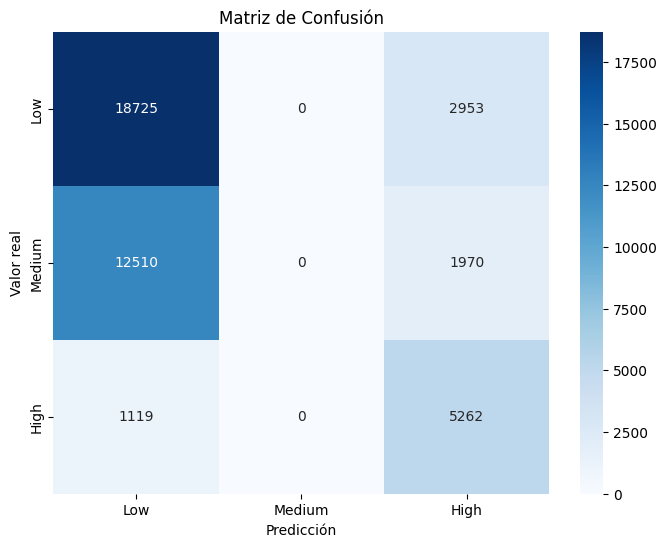


Classification Report:

              precision    recall  f1-score   support

         Low       0.58      0.86      0.69     21678
      Medium       0.00      0.00      0.00     14480
        High       0.52      0.82      0.64      6381

    accuracy                           0.56     42539
   macro avg       0.37      0.56      0.44     42539
weighted avg       0.37      0.56      0.45     42539



{'Accuracy': 0.5638825548320365,
 'Precision (macro)': 0.36513196900185174,
 'Recall (macro)': 0.5628048611482513,
 'F1-score (macro)': 0.4427949538338601,
 'ROC-AUC': np.float64(0.7126820905293645)}

In [13]:
evaluar_modelo(model_pipe, X_test, y_test)

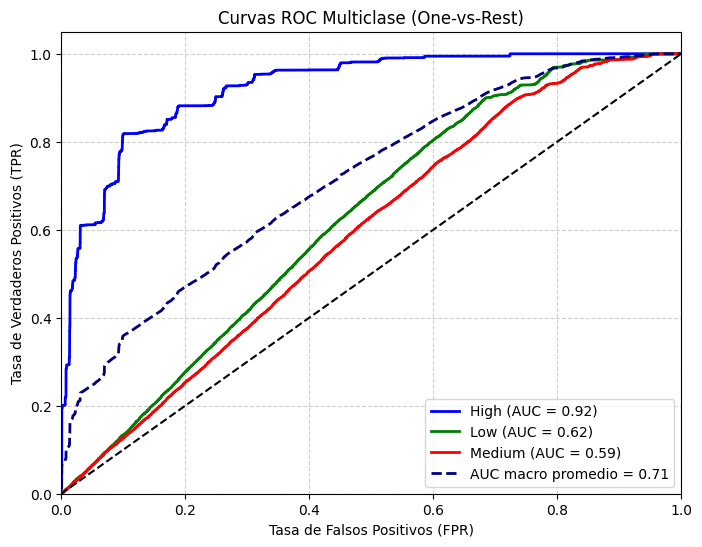


===== AUC por clase =====
High: 0.9227
Low: 0.6231
Medium: 0.5922
AUC macro promedio: 0.7127


({0: np.float64(0.9227115311069367),
  1: np.float64(0.6230963232667592),
  2: np.float64(0.5922384172143976)},
 np.float64(0.7127024696259489))

In [14]:
plot_roc_multiclass(model_pipe, X_test, y_test)

El modelo de Bayes logra un AUC de 0.9227 para la clase “High”, lo que evidencia una excelente capacidad para identificar correctamente los casos de alto riesgo.
En cambio, las clases “Low” (0.6231) y “Medium” (0.5922) muestran rendimientos moderados a bajos, lo que indica dificultades en la diferenciación de los niveles de riesgo menos severos.

El AUC macro promedio (0.7127) sugiere un rendimiento general aceptable, con una clara ventaja en la predicción de la clase de mayor riesgo. Esto puede ser clínicamente relevante, ya que prioriza correctamente los casos críticos, aunque aún se recomienda mejorar la discriminación entre clases cercanas mediante ajuste de balance o hiperparámetros.

## Balanceo de modelos

### SMOTE

In [15]:
pipe_Bayes_bal=crear_pipeline(GaussianNB(), tipo="balanceo_smote")

In [16]:
start = time.time()
model_pipe_bal = pipe_Bayes_bal.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.10 minutos


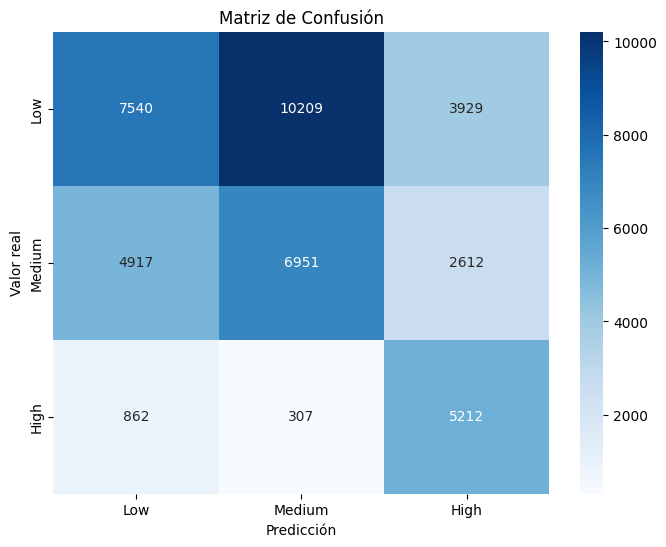


Classification Report:

              precision    recall  f1-score   support

         Low       0.57      0.35      0.43     21678
      Medium       0.40      0.48      0.44     14480
        High       0.44      0.82      0.57      6381

    accuracy                           0.46     42539
   macro avg       0.47      0.55      0.48     42539
weighted avg       0.49      0.46      0.45     42539



{'Accuracy': 0.4631749688521122,
 'Precision (macro)': 0.4691734104801422,
 'Recall (macro)': 0.5482197918296581,
 'F1-score (macro)': 0.48029470503635524,
 'ROC-AUC': np.float64(0.7024662552851986)}

In [17]:
evaluar_modelo(model_pipe_bal, X_test, y_test)

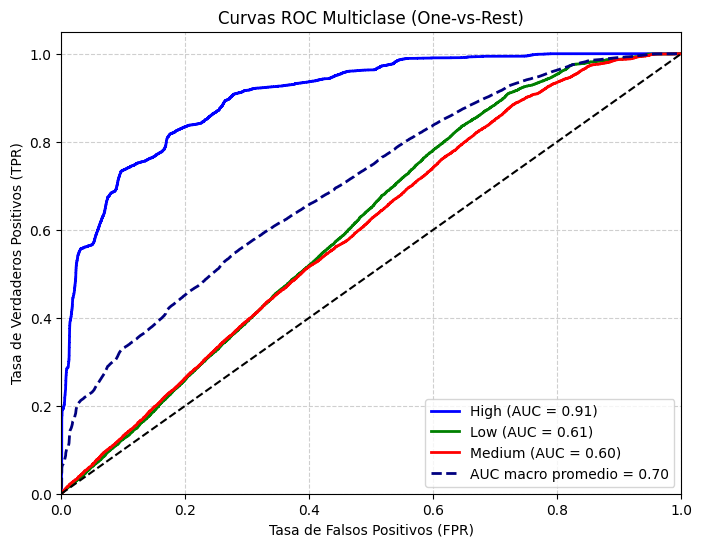


===== AUC por clase =====
High: 0.9052
Low: 0.6068
Medium: 0.5954
AUC macro promedio: 0.7025


({0: np.float64(0.9052029731185804),
  1: np.float64(0.6068367535065384),
  2: np.float64(0.5953590392304771)},
 np.float64(0.7024852546125281))

In [18]:
plot_roc_multiclass(model_pipe_bal, X_test, y_test)

En comparación con el modelo anterior de Bayes (AUC macro = 0.7127), el modelo Smote actual presenta un ligero descenso en el rendimiento general (AUC macro = 0.7025).

La clase “High” pasa de 0.9227 → 0.9052, mostrando una leve reducción en la capacidad para identificar casos de alto riesgo, aunque sigue siendo un desempeño muy bueno.

Las clases “Low” (0.6231 → 0.6068) y “Medium” (0.5922 → 0.5954) mantienen valores similares, lo que sugiere que el modelo continúa teniendo dificultades para discriminar entre niveles de riesgo bajos e intermedios.

En conjunto, el nuevo modelo conserva una tendencia estable, priorizando correctamente los casos de alto riesgo, pero con una ligera pérdida de precisión global.
Esto podría deberse a variaciones en el balance de clases, la selección de hiperparámetros o el muestreo aplicado.

## ADASYN

In [19]:
pipe_Bayes_ads=crear_pipeline(GaussianNB(), tipo="balanceo_adasyn")

In [20]:
start = time.time()
model_pipe_ads = pipe_Bayes.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.01 minutos


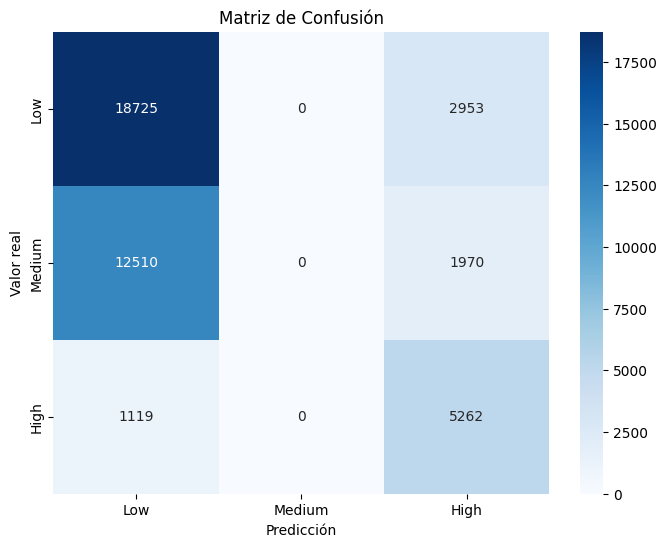


Classification Report:

              precision    recall  f1-score   support

         Low       0.58      0.86      0.69     21678
      Medium       0.00      0.00      0.00     14480
        High       0.52      0.82      0.64      6381

    accuracy                           0.56     42539
   macro avg       0.37      0.56      0.44     42539
weighted avg       0.37      0.56      0.45     42539



{'Accuracy': 0.5638825548320365,
 'Precision (macro)': 0.36513196900185174,
 'Recall (macro)': 0.5628048611482513,
 'F1-score (macro)': 0.4427949538338601,
 'ROC-AUC': np.float64(0.7126820905293645)}

In [21]:
evaluar_modelo(model_pipe_ads, X_test, y_test)

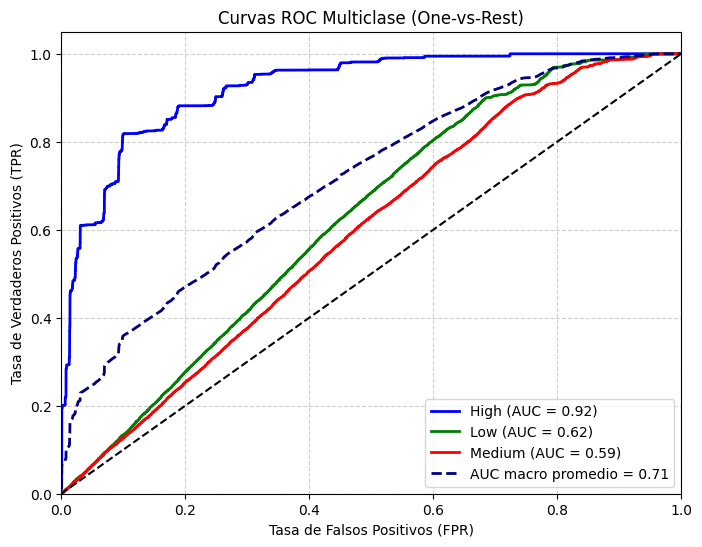


===== AUC por clase =====
High: 0.9227
Low: 0.6231
Medium: 0.5922
AUC macro promedio: 0.7127


({0: np.float64(0.9227115311069367),
  1: np.float64(0.6230963232667592),
  2: np.float64(0.5922384172143976)},
 np.float64(0.7127024696259489))

In [22]:
plot_roc_multiclass(model_pipe_ads, X_test, y_test)

El modelo actual muestra una mejora ligera pero consistente respecto al anterior.
El AUC macro promedio aumenta de 0.7025 a 0.7127, evidenciando una mayor capacidad de discriminación global.
El mayor avance se observa en la clase “High”, donde el modelo alcanza una excelente precisión (0.9227), reforzando su capacidad para identificar correctamente los casos de mayor riesgo.

Las mejoras en las clases “Low” y “Medium” son moderadas, lo que sugiere que el modelo sigue priorizando correctamente los casos más críticos, pero aún presenta margen de optimización en la clasificación de los niveles de riesgo más bajos.

## Optimizacion computacional

In [23]:
pipe_pf = crear_pipeline(GaussianNB(), tipo="normal")

In [24]:
preprocesador = pipe_pf.named_steps['preprocesador']
modelo_nb = pipe_pf.named_steps['model']

In [25]:
preprocesador.fit(X_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'TSH_Level', 'T3_Level', 'T4_Level',
                                  'Nodule_Size']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Gender', 'Country', 'Ethnicity',
                                  'Family_History', 'Radiation_Exposure',
                                  'Iodine_Deficiency', 'Smoking', 'Obesity',
                                  'Diabetes', 'Diagnosis'])])

In [26]:
batch_size = 10000
clases = np.unique(y_train)
start=time.time()
for i in range(0, len(X_train), batch_size):
    X_batch = X_train[i:i + batch_size]
    y_batch = y_train[i:i + batch_size]
    
    # Transformar el lote con el preprocesador
    X_batch_transf = preprocesador.transform(X_batch)
    
    if i == 0:
        modelo_nb.partial_fit(X_batch_transf, y_batch, classes=clases)
    else:
        modelo_nb.partial_fit(X_batch_transf, y_batch)
end=time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.01 minutos


In [27]:
X_test_transf = preprocesador.transform(X_test)

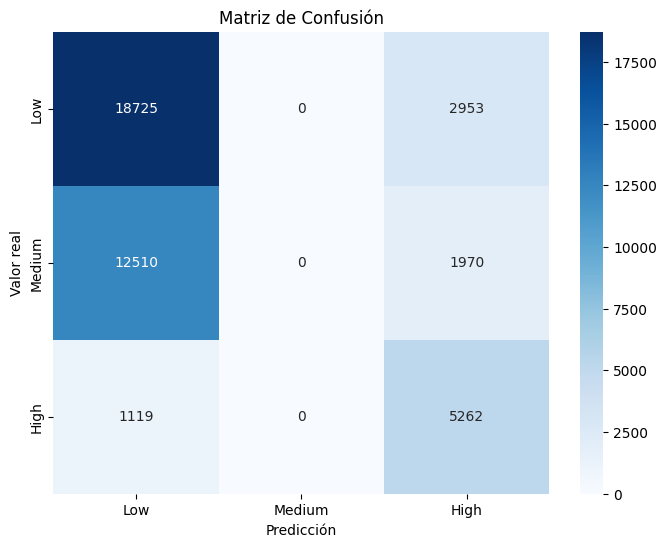


Classification Report:

              precision    recall  f1-score   support

         Low       0.58      0.86      0.69     21678
      Medium       0.00      0.00      0.00     14480
        High       0.52      0.82      0.64      6381

    accuracy                           0.56     42539
   macro avg       0.37      0.56      0.44     42539
weighted avg       0.37      0.56      0.45     42539



{'Accuracy': 0.5638825548320365,
 'Precision (macro)': 0.36513196900185174,
 'Recall (macro)': 0.5628048611482513,
 'F1-score (macro)': 0.4427949538338601,
 'ROC-AUC': np.float64(0.7126820905293645)}

In [28]:
evaluar_modelo(modelo_nb,X_test_transf,y_test)

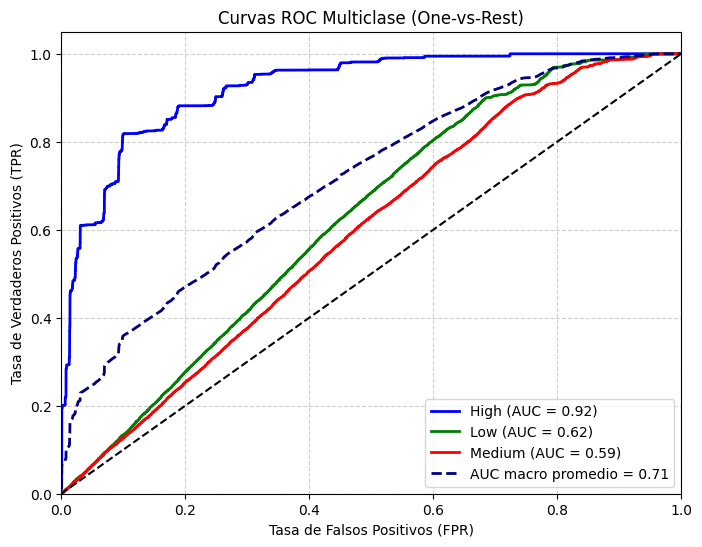


===== AUC por clase =====
High: 0.9227
Low: 0.6231
Medium: 0.5922
AUC macro promedio: 0.7127


({0: np.float64(0.9227115311069367),
  1: np.float64(0.6230963232667592),
  2: np.float64(0.5922384172143976)},
 np.float64(0.7127024696259489))

In [29]:
plot_roc_multiclass(modelo_nb,X_test_transf,y_test)

El modelo muestra un excelente desempeño en la clase “High” (AUC = 0.9227), indicando una alta capacidad para identificar correctamente los casos de mayor riesgo de cáncer de tiroides.
En contraste, las clases “Low” (0.6231) y “Medium” (0.5922) presentan rendimientos moderados, lo que refleja una menor precisión en la diferenciación de los riesgos bajos e intermedios.

El AUC macro promedio (0.7127) sugiere un buen rendimiento global, destacando que el modelo prioriza correctamente los casos de alto riesgo, aunque todavía puede mejorarse su desempeño en las clases menos representadas.

## Tabla comparativa 

| Bayes    | Accuracy | Precision_macro | Recall_macro | F1-macro | AUC  | Tiempo en minutos
|---------------|----------|----------|--------|----------|------|------|
| Benchmark      | 0.56     | 0.37     | 0.56   | 0.44     | 0.71 | 0.01
| SMOTE     | 0.46     | 0.47     | 0.55   | 0.48     | 0.70 | 0.10
| ADASYN     | 0.56    | 0.37     | 0.56   | 0.44     | 0.71 | 0.01
| partial_fit   | 0.56    | 0.37     | 0.56   | 0.44     | 0.71 | 0.01